# Model Training

## Objective
1. Establish a naive baseline using `DummyClassifier`.
2. Train an interpretable baseline using `Logistic Regression`.
3. Train three alternative classifiers: Decision Tree, Random Forest, Gradient Boosting.
4. Evaluate all models on the validation set using multiple metrics.
5. Compare models and select a candidate for final evaluation.

> **Note:** The test set is not used in this notebook. It is reserved for final evaluation only.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/bank_marketing.csv')

# ── Reproduce preprocessing from notebook 03 ──────────────────────────────
# Drop leakage feature
df = df.drop(columns=['duration'])

# Encode target
df['y'] = (df['y'] == 'yes').astype(int)

# Feature engineering
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['<30', '30-40', '40-50', '50-60', '60+']
).astype(str)  # str so OHE handles it easily
df['campaign_capped'] = df['campaign'].clip(upper=int(df['campaign'].quantile(0.95)))

X = df.drop(columns=['y'])
y = df['y']

# Stratified 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Positive rate — Train: {y_train.mean():.3f}  Val: {y_val.mean():.3f}  Test: {y_test.mean():.3f}")


Train: 31,647  Val: 6,782  Test: 6,782
Positive rate — Train: 0.117  Val: 0.117  Test: 0.117


## 2. Shared Preprocessing Pipeline

In [3]:
numerical_features = [
    'age', 'balance', 'day_of_week', 'campaign', 'campaign_capped',
    'pdays', 'previous', 'was_previously_contacted'
]
categorical_features = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome', 'age_group'
]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline,  numerical_features),
    ('cat', cat_pipeline,  categorical_features),
], remainder='drop')

print("Preprocessor ready.")


Preprocessor ready.


In [4]:
def evaluate(name, pipeline, X_tr, y_tr, X_v, y_v):
    """Fit pipeline and evaluate on validation set."""
    pipeline.fit(X_tr, y_tr)
    y_pred  = pipeline.predict(X_v)
    y_proba = pipeline.predict_proba(X_v)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    acc  = accuracy_score(y_v, y_pred)
    prec = precision_score(y_v, y_pred, zero_division=0)
    rec  = recall_score(y_v, y_pred, zero_division=0)
    f1   = f1_score(y_v, y_pred, zero_division=0)
    roc  = roc_auc_score(y_v, y_proba) if y_proba is not None else np.nan
    pr   = average_precision_score(y_v, y_proba) if y_proba is not None else np.nan

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  ROC-AUC:   {roc:.4f}")
    print(f"  PR-AUC:    {pr:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_v, y_pred, target_names=['no (0)', 'yes (1)']))

    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': roc, 'PR-AUC': pr,
        'pipeline': pipeline
    }

results = []


## 3. Baseline — DummyClassifier

A `DummyClassifier` using the `stratified` strategy predicts classes at random according to the training class distribution.
It represents the minimum acceptable performance — any useful model must clearly beat this.


In [5]:
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])
results.append(evaluate("DummyClassifier (baseline)", dummy_pipe, X_train, y_train, X_val, y_val))



  DummyClassifier (baseline)
  Accuracy:  0.7933
  Precision: 0.1062
  Recall:    0.1033
  F1:        0.1047
  ROC-AUC:   0.4940
  PR-AUC:    0.1160

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.88      0.88      0.88      5988
     yes (1)       0.11      0.10      0.10       794

    accuracy                           0.79      6782
   macro avg       0.49      0.49      0.49      6782
weighted avg       0.79      0.79      0.79      6782



## 4. Logistic Regression

An interpretable linear baseline. We use `class_weight='balanced'` to compensate for the class imbalance (~11.7% positive).
`max_iter=1000` to ensure convergence on this many features.


In [6]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])
results.append(evaluate("Logistic Regression", lr_pipe, X_train, y_train, X_val, y_val))



  Logistic Regression
  Accuracy:  0.7681
  Precision: 0.2811
  Recall:    0.6297
  F1:        0.3887
  ROC-AUC:   0.7785
  PR-AUC:    0.4238

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.94      0.79      0.86      5988
     yes (1)       0.28      0.63      0.39       794

    accuracy                           0.77      6782
   macro avg       0.61      0.71      0.62      6782
weighted avg       0.86      0.77      0.80      6782



## 5. Decision Tree

A simple, fully interpretable tree. We limit `max_depth` to prevent overfitting and use `class_weight='balanced'`.
Serves as a reference for rule-based, human-readable prediction.


In [7]:
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
results.append(evaluate("Decision Tree", dt_pipe, X_train, y_train, X_val, y_val))



  Decision Tree
  Accuracy:  0.8238
  Precision: 0.3430
  Recall:    0.5516
  F1:        0.4230
  ROC-AUC:   0.7441
  PR-AUC:    0.3531

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.94      0.86      0.90      5988
     yes (1)       0.34      0.55      0.42       794

    accuracy                           0.82      6782
   macro avg       0.64      0.71      0.66      6782
weighted avg       0.87      0.82      0.84      6782



## 6. Random Forest

An ensemble of trees that reduces overfitting via bagging. Generally strong on tabular data.
`class_weight='balanced'` applied to handle imbalance.


In [8]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
results.append(evaluate("Random Forest", rf_pipe, X_train, y_train, X_val, y_val))



  Random Forest
  Accuracy:  0.8083
  Precision: 0.3297
  Recall:    0.6171
  F1:        0.4298
  ROC-AUC:   0.7940
  PR-AUC:    0.4532

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.94      0.83      0.88      5988
     yes (1)       0.33      0.62      0.43       794

    accuracy                           0.81      6782
   macro avg       0.64      0.73      0.66      6782
weighted avg       0.87      0.81      0.83      6782



## 7. Gradient Boosting

Sequential ensemble that builds trees to correct prior errors.
Often achieves the best performance on structured/tabular data.
We compensate for class imbalance via `subsample` and the `scale_pos_weight` equivalent through careful threshold tuning in the next notebook.


In [9]:
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])
results.append(evaluate("Gradient Boosting", gb_pipe, X_train, y_train, X_val, y_val))



  Gradient Boosting
  Accuracy:  0.8944
  Precision: 0.6345
  Recall:    0.2317
  F1:        0.3395
  ROC-AUC:   0.8074
  PR-AUC:    0.4689

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.91      0.98      0.94      5988
     yes (1)       0.63      0.23      0.34       794

    accuracy                           0.89      6782
   macro avg       0.77      0.61      0.64      6782
weighted avg       0.87      0.89      0.87      6782



## 8. Stratified Cross-Validation (Top Candidates)

We run 5-fold stratified cross-validation on the training set for the three strongest candidates to assess variance and generalisation.


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['f1', 'roc_auc', 'average_precision', 'recall']

for name, pipe in [("Logistic Regression", lr_pipe),
                   ("Random Forest",       rf_pipe),
                   ("Gradient Boosting",   gb_pipe)]:
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"\n{name} — 5-fold CV on training set:")
    print(f"  F1:        {cv_res['test_f1'].mean():.4f}  ± {cv_res['test_f1'].std():.4f}")
    print(f"  ROC-AUC:   {cv_res['test_roc_auc'].mean():.4f}  ± {cv_res['test_roc_auc'].std():.4f}")
    print(f"  PR-AUC:    {cv_res['test_average_precision'].mean():.4f}  ± {cv_res['test_average_precision'].std():.4f}")
    print(f"  Recall:    {cv_res['test_recall'].mean():.4f}  ± {cv_res['test_recall'].std():.4f}")



Logistic Regression — 5-fold CV on training set:
  F1:        0.3891  ± 0.0083
  ROC-AUC:   0.7692  ± 0.0139
  PR-AUC:    0.3973  ± 0.0258
  Recall:    0.6270  ± 0.0212



Random Forest — 5-fold CV on training set:
  F1:        0.4238  ± 0.0133
  ROC-AUC:   0.7892  ± 0.0132
  PR-AUC:    0.4189  ± 0.0275
  Recall:    0.5943  ± 0.0158



Gradient Boosting — 5-fold CV on training set:
  F1:        0.3354  ± 0.0234
  ROC-AUC:   0.7973  ± 0.0145
  PR-AUC:    0.4408  ± 0.0243
  Recall:    0.2293  ± 0.0206


## 9. Model Comparison

In [11]:
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in results
]).set_index('Model').round(4)

print(comparison.to_string())


                            Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                           
DummyClassifier (baseline)    0.7933     0.1062  0.1033  0.1047   0.4940  0.1160
Logistic Regression           0.7681     0.2811  0.6297  0.3887   0.7785  0.4238
Decision Tree                 0.8238     0.3430  0.5516  0.4230   0.7441  0.3531
Random Forest                 0.8083     0.3297  0.6171  0.4298   0.7940  0.4532
Gradient Boosting             0.8944     0.6345  0.2317  0.3395   0.8074  0.4689


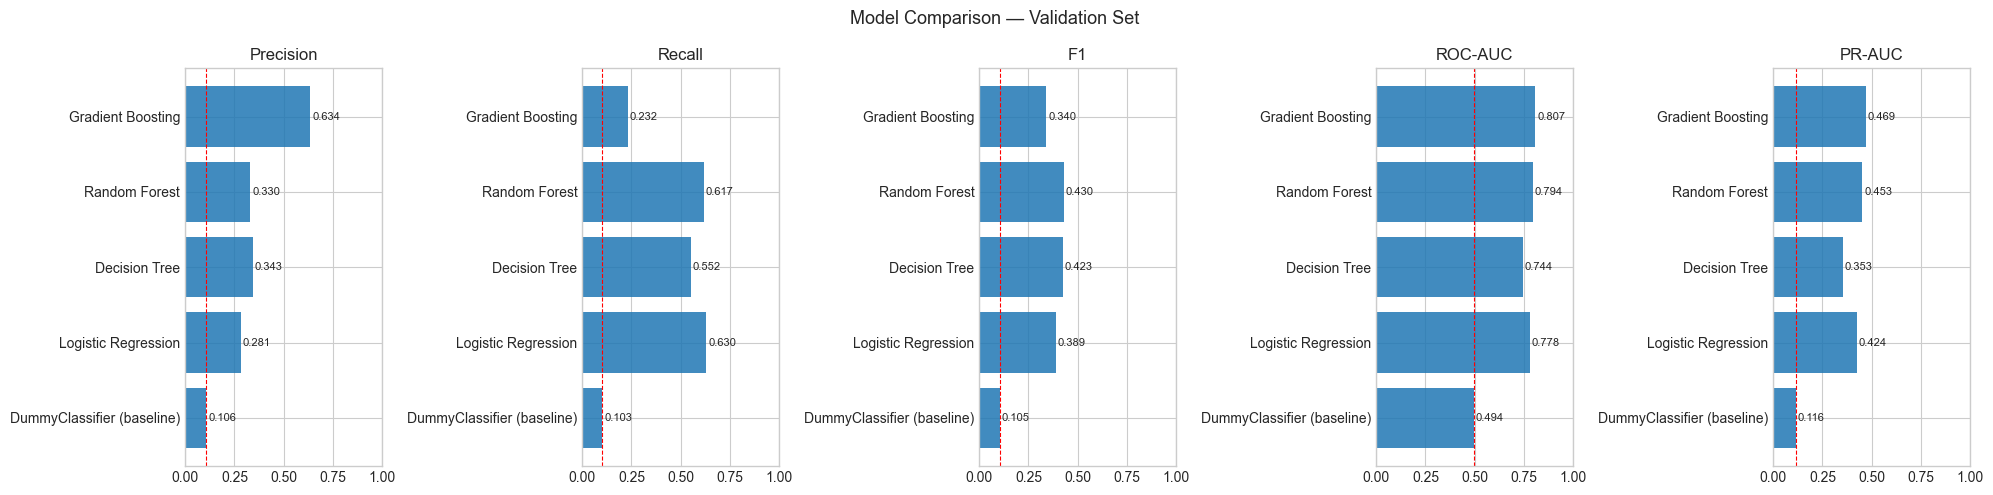

In [12]:
# Visual comparison
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    vals = comparison[metric]
    bars = ax.barh(vals.index, vals.values, alpha=0.85)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    ax.axvline(vals.iloc[0], color='red', linestyle='--', linewidth=0.8, label='Dummy baseline')
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Model Comparison — Validation Set', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Confusion Matrices (Validation Set)

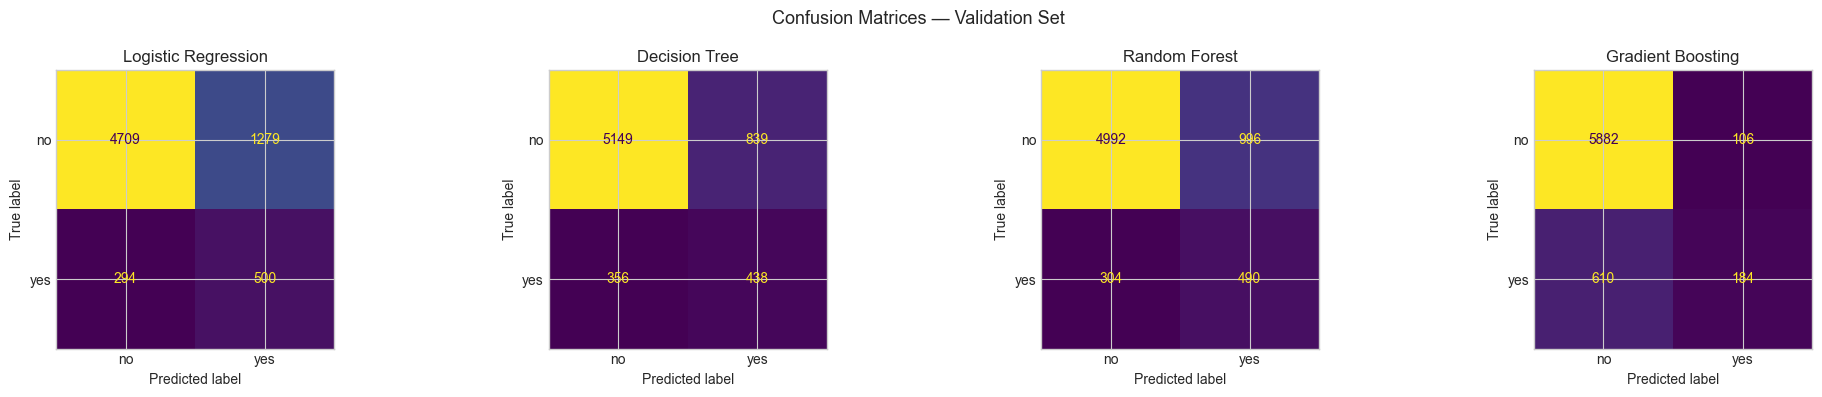

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, res in zip(axes, results[1:]):   # skip Dummy
    cm = confusion_matrix(y_val, res['pipeline'].predict(X_val))
    disp = ConfusionMatrixDisplay(cm, display_labels=['no', 'yes'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(res['Model'])

plt.suptitle('Confusion Matrices — Validation Set', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## Key Findings

> *All numerical values below are produced by running this notebook.*

### Why accuracy alone is insufficient
The dataset is ~88.3% negative. A model predicting 'no' for everyone would achieve ~88% accuracy trivially.
We therefore prioritise **Recall** (catching actual subscribers), **F1** (balance), and **PR-AUC** (performance under imbalance).

### Class imbalance strategy
- `class_weight='balanced'` applied to Logistic Regression, Decision Tree, and Random Forest.
- Gradient Boosting handles imbalance partially via `subsample`; threshold tuning in notebook 05 will compensate.
- No SMOTE applied — class weights are preferred as they do not modify the data distribution.

### Model selection
Results are shown in the comparison table above. The selected candidate for final evaluation will be justified in `reports/decision_log.md` after reviewing the full comparison.

## Decisions Made
- `class_weight='balanced'` used throughout — avoids inflating accuracy on the majority class.
- SMOTE not used — class weights are sufficient given dataset size; avoids overfitting risk.
- Test set remains locked — not touched in this notebook.
- Final model selection deferred to notebook 05 after threshold and error analysis.
